In [124]:
#Librerias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [125]:
#Dataset Raw
data = pd.read_csv('/content/data.txt')
data.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [126]:
#Cracion de columna date para tener una mejor representacion del tiempo
data['date'] = pd.to_datetime(
    data[['year', 'month', 'day', 'hour']]
)

data.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,date
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


In [127]:
#Borrrado de NaN y de la columna 'No' que no aporta informacion fisica ni temporal
data = data.dropna(subset=['pm2.5'])
data_clean = data.drop(columns=['No'])
print("Valores faltantes en pm2.5:", data['pm2.5'].isnull().sum())


Valores faltantes en pm2.5: 0


In [128]:
#Agrego la columna 'date' como mi indice principal
data_clean.set_index('date', inplace=True)
data_clean

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
date,,,,,,,,,,,,
2010-01-02 00:00:00,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0


In [129]:
# Crear los valores históricos de PM2.5
# (lag) -> Variable que representa el valor de una variable en un instante anterior
#PM2.5_lagk​(t)=PM2.5(t−k)
for lag in range(1, 25):
    data_clean[f'pm2.5_lag_{lag}'] = data_clean['pm2.5'].shift(lag)

In [130]:
data_clean

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,...,pm2.5_lag_15,pm2.5_lag_16,pm2.5_lag_17,pm2.5_lag_18,pm2.5_lag_19,pm2.5_lag_20,pm2.5_lag_21,pm2.5_lag_22,pm2.5_lag_23,pm2.5_lag_24
date,,,,,,,,,,,,,,,,,,,,,
2010-01-02 00:00:00,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02 01:00:00,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02 02:00:00,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02 03:00:00,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02 04:00:00,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,...,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0,35.0
2014-12-31 20:00:00,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,...,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0
2014-12-31 21:00:00,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,...,8.0,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0


In [132]:
#Se eliminan esas filas con NaN, ya que no contaban con valores de pm2.5 historicos anteriores
data_clean = data_clean.dropna().reset_index(drop=True)
data_clean

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,...,pm2.5_lag_15,pm2.5_lag_16,pm2.5_lag_17,pm2.5_lag_18,pm2.5_lag_19,pm2.5_lag_20,pm2.5_lag_21,pm2.5_lag_22,pm2.5_lag_23,pm2.5_lag_24
0,2010,1,3,0,90.0,-7,-6.0,1027.0,SE,58.56,...,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0,148.0,129.0
1,2010,1,3,1,63.0,-8,-6.0,1026.0,SE,61.69,...,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0,148.0
2,2010,1,3,2,65.0,-8,-7.0,1026.0,SE,65.71,...,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0
3,2010,1,3,3,55.0,-8,-7.0,1025.0,SE,68.84,...,148.0,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0
4,2010,1,3,4,65.0,-8,-7.0,1024.0,SE,72.86,...,164.0,148.0,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41728,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,...,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0,35.0
41729,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,...,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0
41730,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,...,8.0,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0
41731,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,...,8.0,8.0,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0


In [133]:
#Configuracion de caracteristicas de entrada y lag
features = [
    'DEWP',
    'TEMP',
    'PRES',
    'cbwd',
    'Iws',
    'Is',
    'Ir'
]
lag_features = [
    f'pm2.5_lag_{lag}'
    for lag in range(1, 25)
]
y = data_clean['pm2.5']

features = features + lag_features

X = data_clean[features]
X

,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,pm2.5_lag_1,pm2.5_lag_2,pm2.5_lag_3,...,pm2.5_lag_15,pm2.5_lag_16,pm2.5_lag_17,pm2.5_lag_18,pm2.5_lag_19,pm2.5_lag_20,pm2.5_lag_21,pm2.5_lag_22,pm2.5_lag_23,pm2.5_lag_24
0,-7,-6.0,1027.0,SE,58.56,4,0,126.0,156.0,164.0,...,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0,148.0,129.0
1,-8,-6.0,1026.0,SE,61.69,5,0,90.0,126.0,156.0,...,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0,148.0
2,-8,-7.0,1026.0,SE,65.71,6,0,63.0,90.0,126.0,...,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0,159.0
3,-8,-7.0,1025.0,SE,68.84,7,0,65.0,63.0,90.0,...,148.0,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0,181.0
4,-8,-7.0,1024.0,SE,72.86,8,0,55.0,65.0,63.0,...,164.0,148.0,152.0,140.0,132.0,120.0,124.0,105.0,109.0,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41728,-23,-2.0,1034.0,NW,231.97,0,0,10.0,9.0,8.0,...,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0,35.0
41729,-22,-3.0,1034.0,NW,237.78,0,0,8.0,10.0,9.0,...,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0,26.0
41730,-22,-3.0,1034.0,NW,242.70,0,0,10.0,8.0,10.0,...,8.0,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0,20.0
41731,-22,-4.0,1034.0,NW,246.72,0,0,10.0,10.0,8.0,...,8.0,8.0,9.0,8.0,9.0,20.0,11.0,10.0,16.0,8.0


In [134]:
# Se aplica One-Hot Encoding, que permite transformar la variable en columnas numericas binarias
#Crea una columna nueva por cada valor que puede tomar la variable
X = pd.get_dummies(
    X,
    columns=['cbwd'],
    dtype=int
)


In [97]:
X

,DEWP,TEMP,PRES,Iws,Is,Ir,pm2.5_lag_1,pm2.5_lag_2,pm2.5_lag_3,pm2.5_lag_4,...,pm2.5_lag_19,pm2.5_lag_20,pm2.5_lag_21,pm2.5_lag_22,pm2.5_lag_23,pm2.5_lag_24,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
0,-7,-6.0,1027.0,58.56,4,0,126.0,156.0,164.0,154.0,...,109.0,138.0,181.0,159.0,148.0,129.0,0,0,1,0
1,-8,-6.0,1026.0,61.69,5,0,90.0,126.0,156.0,164.0,...,105.0,109.0,138.0,181.0,159.0,148.0,0,0,1,0
2,-8,-7.0,1026.0,65.71,6,0,63.0,90.0,126.0,156.0,...,124.0,105.0,109.0,138.0,181.0,159.0,0,0,1,0
3,-8,-7.0,1025.0,68.84,7,0,65.0,63.0,90.0,126.0,...,120.0,124.0,105.0,109.0,138.0,181.0,0,0,1,0
4,-8,-7.0,1024.0,72.86,8,0,55.0,65.0,63.0,90.0,...,132.0,120.0,124.0,105.0,109.0,138.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41728,-23,-2.0,1034.0,231.97,0,0,10.0,9.0,8.0,11.0,...,10.0,16.0,8.0,20.0,26.0,35.0,0,1,0,0
41729,-22,-3.0,1034.0,237.78,0,0,8.0,10.0,9.0,8.0,...,11.0,10.0,16.0,8.0,20.0,26.0,0,1,0,0
41730,-22,-3.0,1034.0,242.70,0,0,10.0,8.0,10.0,9.0,...,20.0,11.0,10.0,16.0,8.0,20.0,0,1,0,0
41731,-22,-4.0,1034.0,246.72,0,0,10.0,10.0,8.0,10.0,...,9.0,20.0,11.0,10.0,16.0,8.0,0,1,0,0


In [135]:
#conjunto de datos de entrenamiento, validacion y prueba

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Datos de entrenamiento
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Datos de validación
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Datos de prueba
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nRango temporal:")

print("Train:", data['date'].iloc[0], "→", data['date'].iloc[train_end - 1])

print("Val:", data['date'].iloc[train_end], "→", data['date'].iloc[val_end - 1])

print("Test:", data['date'].iloc[val_end], "→", data['date'].iloc[-1])

X_train: (29213, 34)
y_train: (29213,)
X_val: (6260, 34)
y_val: (6260,)
X_test: (6260, 34)
y_test: (6260,)

Rango temporal:
Train: 2010-01-02 00:00:00 → 2013-07-21 06:00:00
Val: 2013-07-21 07:00:00 → 2014-04-10 11:00:00
Test: 2014-04-10 12:00:00 → 2014-12-31 23:00:00


### Modelo

In [137]:
#Configuracion del modelo XGBoost
model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=20

)

#Entrenamiento del modelo
model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [138]:


results = model.evals_result()

print(results.keys())

dict_keys(['validation_0', 'validation_1'])


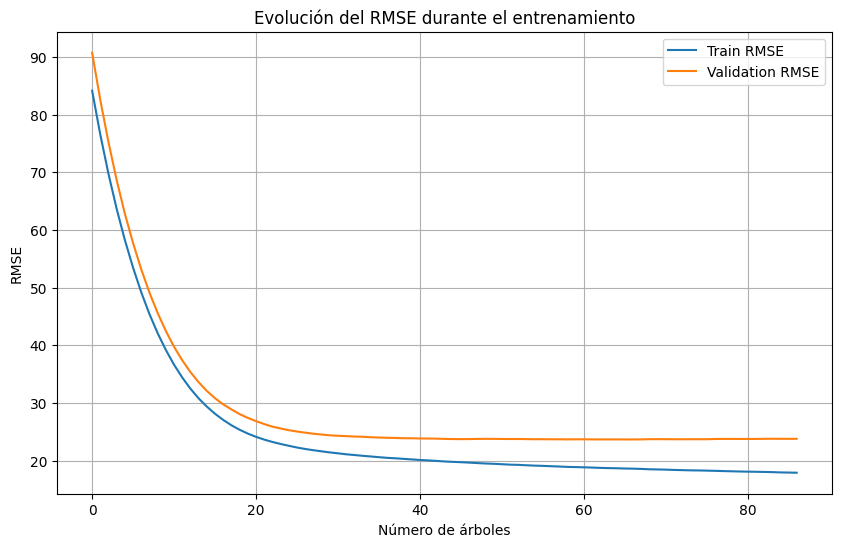

In [139]:
import matplotlib.pyplot as plt

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure(figsize=(10, 6))

plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')

plt.xlabel('Número de árboles')
plt.ylabel('RMSE')
plt.title('Evolución del RMSE durante el entrenamiento')

plt.legend()
plt.grid(True)

plt.show()

### Prediccion

In [140]:
y_pred = model.predict(X_test)
# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R²
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  10.5533
MSE:  317.4529
RMSE: 17.8172
R²:   0.9493


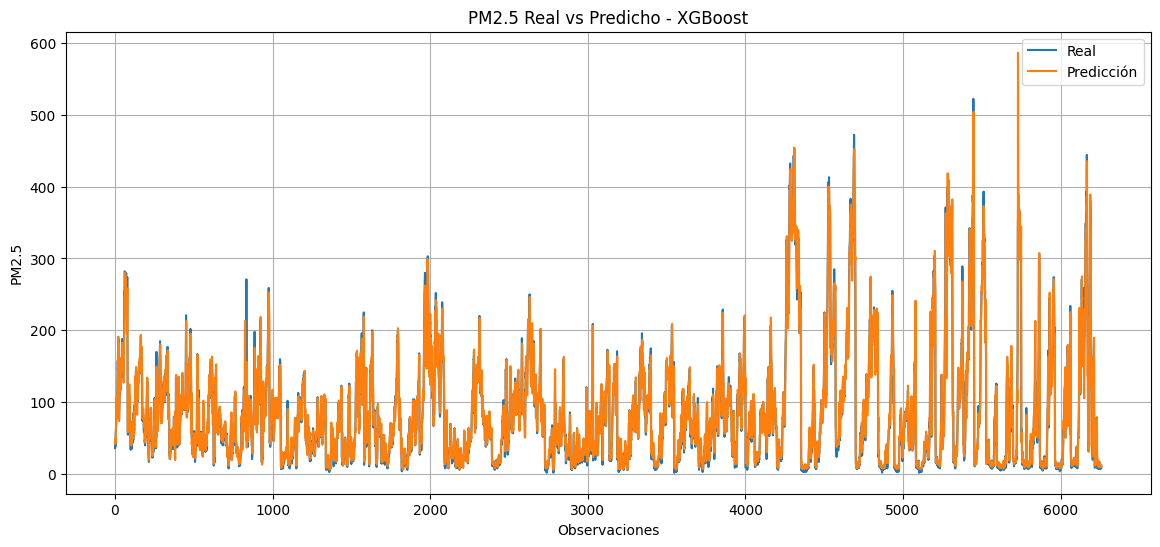

In [141]:
#Grafica de la prediccion

plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Predicción')

plt.xlabel('Observaciones')
plt.ylabel('PM2.5')
plt.title('PM2.5 Real vs Predicho - XGBoost')

plt.legend()
plt.grid(True)

plt.show()

In [142]:
#Calculo de la importancia de las variables
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

pm2.5_lag_1     0.819534
cbwd_NW         0.009676
DEWP            0.009218
Ir              0.008991
pm2.5_lag_2     0.008793
pm2.5_lag_19    0.008731
pm2.5_lag_6     0.008366
pm2.5_lag_3     0.007209
pm2.5_lag_22    0.007088
pm2.5_lag_17    0.006775
Iws             0.006595
cbwd_NE         0.006517
pm2.5_lag_15    0.006483
TEMP            0.006453
pm2.5_lag_24    0.005931
PRES            0.005546
pm2.5_lag_18    0.005390
pm2.5_lag_8     0.005060
pm2.5_lag_4     0.004854
pm2.5_lag_23    0.004613
dtype: float32


Se observa que la variable pm2.5_lag_1 aporta mayor información al modelo. Es decir que, el modelo basta con usar solo el lag_1 para realizar una buena predicción. Se hará la prueba usando solo los features + lag_1

In [143]:
# Utilizar únicamente el PM2.5 de la hora anterior
X_lag1_train = X_train[['pm2.5_lag_1']]
X_lag1_val = X_val[['pm2.5_lag_1']]
X_lag1_test = X_test[['pm2.5_lag_1']]


#Entrenamiento del modelo
model.fit(
    X_lag1_train,
    y_train,
    eval_set=[
        (X_lag1_train, y_train),
        (X_lag1_val, y_val)
    ],
    verbose=False
)

y_pred = model.predict(X_lag1_test)
# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R²
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  11.1124
MSE:  353.6447
RMSE: 18.8054
R²:   0.9435


El resultado es positivo, teniendo en cuenta que se usa una sola caracteristica para entrenar el modelo, apesar que baja un poco en cuanto al $R^2$. Sin embargo, hablando en terminos de rendimiento y costo, sería una buena opción de implementación real.